# Paper-Faithful Count MGD Comparison

A deterministic correctness comparison between the repository's persistent softmax-weighting idea and the paper's count-based dataset-selection method.

This is **not** an ImageNet-scale scientific result. It uses a one-parameter reconstruction model and a tiny synthetic pool so the only moving part is the curation mechanism.

## Methods held to the same inner-training setup

Every method restarts from the same model initialization and uses the same candidate pool, held-out objective, Smooth AdamW configuration, masks, inner-step count, and per-step sample budget.

- **Uniform:** no curation.
- **Persistent cluster softmax:** one persistent weight per useful/distractor cluster.
- **Persistent per-sample softmax:** one persistent weight per candidate; a smooth proxy, not the paper method.
- **Paper projected sign:** integer counts with Algorithm 1's projected signed update.
- **Paper fixed-budget ranked:** integer counts with Appendix C.2's balanced ranked exchange.

In [1]:
from __future__ import annotations

from types import SimpleNamespace

import matplotlib.pyplot as plt
import torch
from torch import Tensor, nn

from functional_train import SmoothAdamWConfig, initialize_train_state
from metagrad import InnerBatch, ObjectiveBatch
from paper_mgd import CandidatePool, PaperMGDConfig, initialize_counts, paper_mgd_outer_step
from replay import replay_metagradient, replay_objective
from weighting import group_masses

torch.manual_seed(0)
torch.set_default_dtype(torch.float64)
device = torch.device("cpu")
print("torch", torch.__version__, "| device", device, "| dtype", torch.get_default_dtype())

torch 2.8.0+cu128 | device cpu | dtype torch.float64


In [2]:
class ConstantPatchModel(nn.Module):
    """A one-parameter masked-reconstruction model that makes curation easy to inspect."""

    def __init__(self) -> None:
        super().__init__()
        self.config = SimpleNamespace(num_patches=1, mask_ratio=1.0)
        self.prediction = nn.Parameter(torch.tensor(0.0))

    def forward(self, images: Tensor, patch_mask: Tensor) -> Tensor:
        return self.prediction.expand(images.shape[0], 1, 3 * 2 * 2)


model = ConstantPatchModel().to(device)
initial_state = initialize_train_state(model)

# Candidates 0-1 match the held-out target (useful); candidates 2-3 are distractors.
useful_images = torch.ones(2, 3, 2, 2, device=device)
distractor_images = torch.zeros(2, 3, 2, 2, device=device)
candidate_images = torch.cat((useful_images, distractor_images))
candidate_ids = torch.tensor([10, 11, 12, 13])
pool = CandidatePool(candidate_images, candidate_ids)

train_mask = torch.ones(4, 1, dtype=torch.bool, device=device)
objective_batch = ObjectiveBatch(
    torch.ones(2, 3, 2, 2, device=device),
    torch.ones(2, 1, dtype=torch.bool, device=device),
)
optimizer_config = SmoothAdamWConfig(
    learning_rate=0.1, betas=(0.8, 0.9), eps=0.1, weight_decay=0.0
)
inner_steps = 3
meta_steps = 4

print("candidate order: [useful, useful, distractor, distractor]")
print("fixed sample budget per outer step:", inner_steps * candidate_images.shape[0])

candidate order: [useful, useful, distractor, distractor]
fixed sample budget per outer step: 12


In [3]:
def persistent_trajectory(group_ids: Tensor) -> tuple[InnerBatch, ...]:
    return tuple(
        InnerBatch(candidate_images, train_mask, group_ids)
        for _ in range(inner_steps)
    )


def run_persistent_softmax(
    name: str,
    group_ids: Tensor,
    base_masses: Tensor,
    useful_groups: tuple[int, ...],
) -> list[dict]:
    logits = torch.zeros(base_masses.numel(), requires_grad=True)
    trajectory = persistent_trajectory(group_ids)
    history = []
    for step in range(meta_steps + 1):
        phi, gradient = replay_metagradient(
            model,
            initial_state,
            trajectory,
            objective_batch,
            logits,
            base_masses,
            optimizer_config,
            temperature=0.5,
            branching_factor=3,
        )
        masses = group_masses(logits.detach(), temperature=0.5)
        history.append(
            {
                "method": name,
                "step": step,
                "objective": phi.item(),
                "useful_mass": masses[list(useful_groups)].sum().item(),
                "total_count": 4,
                "distribution": [round(value, 3) for value in masses.tolist()],
            }
        )
        if step < meta_steps:
            logits = (logits.detach() - 0.25 * gradient.sign()).requires_grad_(True)
    return history


def run_count_mgd(name: str, policy: str) -> list[dict]:
    counts = initialize_counts(pool.num_candidates)
    config = PaperMGDConfig(
        inner_steps=inner_steps,
        batch_size=4,
        perturbation_step=1,
        update_policy=policy,
        coordinate_fraction=1.0,
        exchange_fraction=0.5,
        mask_seed=5,
        probe_mask_seed=6,
        shuffle_seed=7,
        selection_seed=8,
        branching_factor=3,
    )
    history = []
    for step in range(meta_steps + 1):
        result = paper_mgd_outer_step(
            model,
            initial_state,
            pool,
            counts,
            objective_batch,
            optimizer_config,
            config,
            outer_step=step,
        )
        history.append(
            {
                "method": name,
                "step": step,
                "objective": result.objective.item(),
                "useful_mass": (counts[:2].sum() / counts.sum()).item(),
                "total_count": int(counts.sum()),
                "distribution": counts.tolist(),
            }
        )
        counts = result.updated_counts
    return history

In [4]:
cluster_ids = torch.tensor([0, 0, 1, 1])
sample_ids = torch.arange(4)
cluster_base = torch.tensor([0.5, 0.5])
sample_base = torch.full((4,), 0.25)

uniform_phi = replay_objective(
    model,
    initial_state,
    persistent_trajectory(cluster_ids),
    objective_batch,
    torch.zeros(2),
    cluster_base,
    optimizer_config,
    temperature=0.5,
    branching_factor=3,
).item()

uniform = [{
    "method": "uniform",
    "step": 0,
    "objective": uniform_phi,
    "useful_mass": 0.5,
    "total_count": 4,
    "distribution": [1, 1, 1, 1],
}]
cluster_softmax = run_persistent_softmax(
    "persistent cluster softmax", cluster_ids, cluster_base, (0,)
)
sample_softmax = run_persistent_softmax(
    "persistent per-sample softmax", sample_ids, sample_base, (0, 1)
)
paper_projected = run_count_mgd("paper projected sign", "projected_sign")
paper_fixed = run_count_mgd("paper fixed-budget ranked", "fixed_budget_ranked")

histories = [uniform, cluster_softmax, sample_softmax, paper_projected, paper_fixed]
print("completed", sum(len(history) for history in histories), "method/step evaluations")

completed 21 method/step evaluations


In [5]:
print(f"{'method':<31} {'final phi':>11} {'useful mass':>13} {'total count':>13}  final distribution")
print("-" * 100)
for history in histories:
    final = history[-1]
    print(
        f"{final['method']:<31} {final['objective']:>11.6f} "
        f"{final['useful_mass']:>13.3f} {final['total_count']:>13}  {final['distribution']}"
    )

print("\nOuter-step trajectories for the paper count methods:")
for history in (paper_projected, paper_fixed):
    print("\n", history[0]["method"])
    for row in history:
        print(
            f"step={row['step']} phi={row['objective']:.6f} "
            f"useful_mass={row['useful_mass']:.3f} total={row['total_count']} "
            f"counts={row['distribution']}"
        )

method                            final phi   useful mass   total count  final distribution
----------------------------------------------------------------------------------------------------
uniform                            0.499867         0.500             4  [1, 1, 1, 1]
persistent cluster softmax         0.493076         0.982             4  [0.982, 0.018]
persistent per-sample softmax      0.493076         0.982             4  [0.491, 0.491, 0.009, 0.009]
paper projected sign               0.492989         1.000            10  [5, 5, 0, 0]
paper fixed-budget ranked          0.492989         1.000             4  [2, 2, 0, 0]

Outer-step trajectories for the paper count methods:

 paper projected sign
step=0 phi=0.499867 useful_mass=0.500 total=4 counts=[1, 1, 1, 1]
step=1 phi=0.492989 useful_mass=1.000 total=4 counts=[2, 2, 0, 0]
step=2 phi=0.492989 useful_mass=1.000 total=6 counts=[3, 3, 0, 0]
step=3 phi=0.492989 useful_mass=1.000 total=8 counts=[4, 4, 0, 0]
step=4 phi=0.49298

In [6]:
histories

[[{'method': 'uniform',
   'step': 0,
   'objective': 0.49986715719518476,
   'useful_mass': 0.5,
   'total_count': 4,
   'distribution': [1, 1, 1, 1]}],
 [{'method': 'persistent cluster softmax',
   'step': 0,
   'objective': 0.49986715719518476,
   'useful_mass': 0.5,
   'total_count': 4,
   'distribution': [0.5, 0.5]},
  {'method': 'persistent cluster softmax',
   'step': 1,
   'objective': 0.49499019121010196,
   'useful_mass': 0.7310585786300049,
   'total_count': 4,
   'distribution': [0.731, 0.269]},
  {'method': 'persistent cluster softmax',
   'step': 2,
   'objective': 0.49366050125137867,
   'useful_mass': 0.8807970779778823,
   'total_count': 4,
   'distribution': [0.881, 0.119]},
  {'method': 'persistent cluster softmax',
   'step': 3,
   'objective': 0.49322761960902656,
   'useful_mass': 0.9525741268224334,
   'total_count': 4,
   'distribution': [0.953, 0.047]},
  {'method': 'persistent cluster softmax',
   'step': 4,
   'objective': 0.4930756708777006,
   'useful_mass'

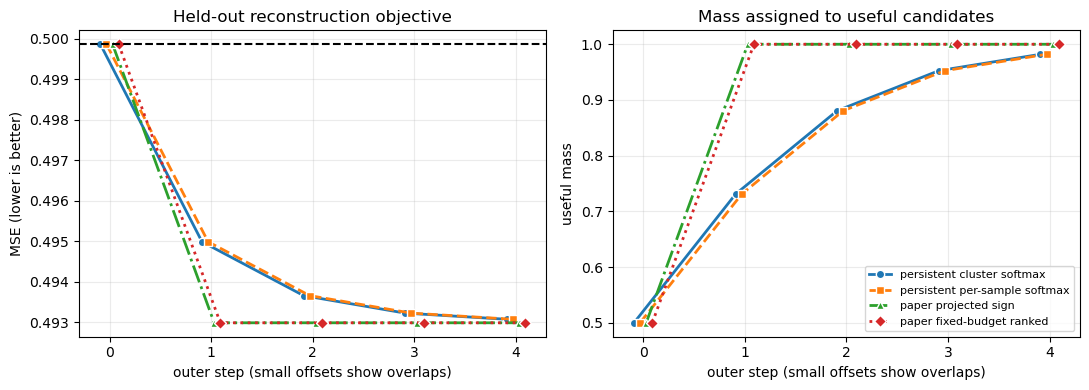

Visibility note: cluster/per-sample softmax overlap exactly, and the two paper methods
overlap exactly on these plotted metrics. Horizontal offsets reveal all four series.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Several methods land on exactly identical trajectories in this deliberately
# symmetric toy problem. Tiny horizontal offsets make every series visible;
# they change only the drawing position, never the measured values.
styles = [
    ("persistent cluster softmax", "C0", "o", "-", -0.09),
    ("persistent per-sample softmax", "C1", "s", "--", -0.03),
    ("paper projected sign", "C2", "^", "-.", 0.03),
    ("paper fixed-budget ranked", "C3", "D", ":", 0.09),
]
history_by_name = {history[0]["method"]: history for history in histories[1:]}

for name, color, marker, linestyle, x_offset in styles:
    history = history_by_name[name]
    shifted_steps = [row["step"] + x_offset for row in history]
    common_style = dict(
        color=color,
        marker=marker,
        linestyle=linestyle,
        linewidth=2,
        markersize=6,
        markeredgecolor="white",
        label=name,
    )
    axes[0].plot(
        shifted_steps,
        [row["objective"] for row in history],
        **common_style,
    )
    axes[1].plot(
        shifted_steps,
        [row["useful_mass"] for row in history],
        **common_style,
    )

axes[0].axhline(uniform_phi, color="black", linestyle="--", label="uniform")
axes[0].set_title("Held-out reconstruction objective")
axes[0].set_xlabel("outer step (small offsets show overlaps)")
axes[0].set_ylabel("MSE (lower is better)")
axes[1].set_title("Mass assigned to useful candidates")
axes[1].set_xlabel("outer step (small offsets show overlaps)")
axes[1].set_ylabel("useful mass")
for axis in axes:
    axis.set_xticks(range(meta_steps + 1))
    axis.grid(alpha=0.25)
axes[1].legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

print("Visibility note: cluster/per-sample softmax overlap exactly, and the two paper methods")
print("overlap exactly on these plotted metrics. Horizontal offsets reveal all four series.")

## Reading the comparison

- The persistent softmax methods optimize a smooth distribution that affects **every** inner step.
- The paper methods optimize integer candidate counts. Their metagradient comes from a continuous perturbation injected at **one** inner step, then the outer update changes the next trajectory's repeated samples.
- `projected_sign` may change the total count; the fixed per-step sample budget is still preserved by cycling or truncating the count-derived schedule.
- `fixed_budget_ranked` exchanges equal numbers of counts, so its total count remains constant and removed candidates can return later.

The synthetic target makes useful candidates obvious. The purpose of this notebook is to confirm the implementations respond in the expected direction before running a real comparison.